### COMP 3610 Project
#### Feature Selection and Synthetic Data Generation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_absolute_error, accuracy_score
from sklearn.neighbors import KNeighborsRegressor

In [3]:
from xgboost import XGBRegressor

In [23]:
df_original = pd.read_csv('Solar Dataset.csv')

In [13]:
df_original.columns

Index(['Day of Year', 'Year', 'Month', 'Day', 'First Hour of Period',
       'Is Daylight', 'Distance to Solar Noon', 'Average Temperature (Day)',
       'Average Wind Direction (Day)', 'Average Wind Speed (Day)', 'Sky Cover',
       'Visibility', 'Relative Humidity', 'Average Wind Speed (Period)',
       'Average Barometric Pressure (Period)', 'Power Generated'],
      dtype='object')

In [14]:
df_original.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2920 entries, 0 to 2919
Data columns (total 16 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Day of Year                           2920 non-null   int64  
 1   Year                                  2920 non-null   int64  
 2   Month                                 2920 non-null   int64  
 3   Day                                   2920 non-null   int64  
 4   First Hour of Period                  2920 non-null   int64  
 5   Is Daylight                           2920 non-null   bool   
 6   Distance to Solar Noon                2920 non-null   float64
 7   Average Temperature (Day)             2920 non-null   int64  
 8   Average Wind Direction (Day)          2920 non-null   int64  
 9   Average Wind Speed (Day)              2920 non-null   float64
 10  Sky Cover                             2920 non-null   int64  
 11  Visibility       

Removing null entries and converting bool column to int.

In [24]:
df_original = df_original.dropna(how = 'any', axis =0)
df_original['Is Daylight'] = df_original['Is Daylight'].astype(int)

# Step 1 - Preprocessing the data set

## Time features
1) Year - The dataset is take over two years (2023 and 2024). This is not enought values to determine trends. Year will be dropped.
2) Month - Very useful as the change in seasons will effect the power generated but it is not as useful as Day of the year.
3) Day - Gives which day of the month it is. Not useful without relation to the month.
4) Day of the year - This is the best way to represent time in the data set as it can capture the change in seasons in a smooth way throughout the year. This will be the feature used to represent date.
5) First hour of period - This will be used as power generation depends on time of day.

## Sine and cosine encoding
Since the 1st day of the year and the last day of the year are adjacent to each other in terms of solar position and simlary the first and last hour of the day. To get better meaning out of these features, sine and cosine encoding will be applied.

## Other features
The cnn part of the CNN-LTSM model learns what combination of features over time are useful for the prediction task. Therefore all the other features will be kept in. All the features will be scaled between a specific range so all features will have equal weight.

In [25]:
#Step 1: Sin and Cos encoding
df_original['day_of_year_sin'] = np.sin(2 * np.pi * df_original['Day of Year'] / 365)
df_original['day_of_year_cos'] = np.cos(2 * np.pi * df_original['Day of Year'] / 365)

df_original['hour_sin'] = np.sin(2 * np.pi * df_original['First Hour of Period'] / 24)
df_original['hour_cos'] = np.cos(2 * np.pi * df_original['First Hour of Period'] / 24)

# Step 2: Drop original cyclical features
df_original.drop(['Day of Year', 'First Hour of Period', 'Year', 'Month', 'Day'], axis=1, inplace=True)

# Step 3: Scale all other features
cyclical_cols = ['day_of_year_sin', 'day_of_year_cos', 'hour_sin', 'hour_cos']
numerical_cols =df_original.columns.drop(['day_of_year_sin', 'day_of_year_cos', 'hour_sin', 'hour_cos','Power Generated'])

scaler = MinMaxScaler()
df_original[numerical_cols] = scaler.fit_transform(df_original[numerical_cols])

### Feature Analysis
Correlation Analysis of relevant features

In [29]:
#features = feature_columns + ['Power Generated']
correlation_matrix = df_original.corr()

Power Generated                         1.000000
Is Daylight                             0.532336
Average Wind Speed (Period)             0.278174
Average Wind Direction (Day)            0.146463
Average Wind Speed (Day)                0.142366
Average Temperature (Day)               0.132155
Visibility                              0.075841
day_of_year_sin                         0.043684
Average Barometric Pressure (Period)   -0.036553
hour_sin                               -0.119244
Sky Cover                              -0.187248
day_of_year_cos                        -0.223721
Relative Humidity                      -0.522445
Distance to Solar Noon                 -0.746825
hour_cos                               -0.757251
Name: Power Generated, dtype: float64

Random Forest Feature Importance Analysis

In [30]:
x = df_original.drop(columns=["Power Generated"])  # Features
y = df_original["Power Generated"]  # Target
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.2)
clf = RandomForestClassifier()
clf.fit(x_train, y_train)

RandomForestClassifier()

In [31]:
feature_importances = clf.feature_importances_
features = x.columns

In [32]:
feature_importances = clf.feature_importances_
features = x.columns
feature_importance_df = pd.DataFrame({"Feature": features, "Importance": feature_importances})
# Sort the features by importance in descending order
feature_importance_df = feature_importance_df.sort_values(by="Importance", ascending=False)

In [ ]:
# Mean Decrease Accuracy
'''importance = []
acc = accuracy_score(y_test, clf.predict(x_test))
for i in range(x.shape[1]):
    x_test_copy = x_test.copy()
    np.random.shuffle(x_test_copy.iloc[:, i].values)
    shuff_accuracy = accuracy_score(y_test, clf.predict(x_test_copy))
    importance.append(acc - shuff_accuracy)
accuracy_df = pd.DataFrame({'Feature': features, 'Decrease in Accuracy': importance}).sort_values('Decrease in Accuracy', ascending=False)
print(accuracy_df)'''

In [33]:
print(correlation_matrix['Power Generated'].sort_values(ascending=False))
print(feature_importance_df)

Power Generated                         1.000000
Is Daylight                             0.532336
Average Wind Speed (Period)             0.278174
Average Wind Direction (Day)            0.146463
Average Wind Speed (Day)                0.142366
Average Temperature (Day)               0.132155
Visibility                              0.075841
day_of_year_sin                         0.043684
Average Barometric Pressure (Period)   -0.036553
hour_sin                               -0.119244
Sky Cover                              -0.187248
day_of_year_cos                        -0.223721
Relative Humidity                      -0.522445
Distance to Solar Noon                 -0.746825
hour_cos                               -0.757251
Name: Power Generated, dtype: float64
                                 Feature  Importance
1                 Distance to Solar Noon    0.178926
13                              hour_cos    0.093259
0                            Is Daylight    0.081320
11             

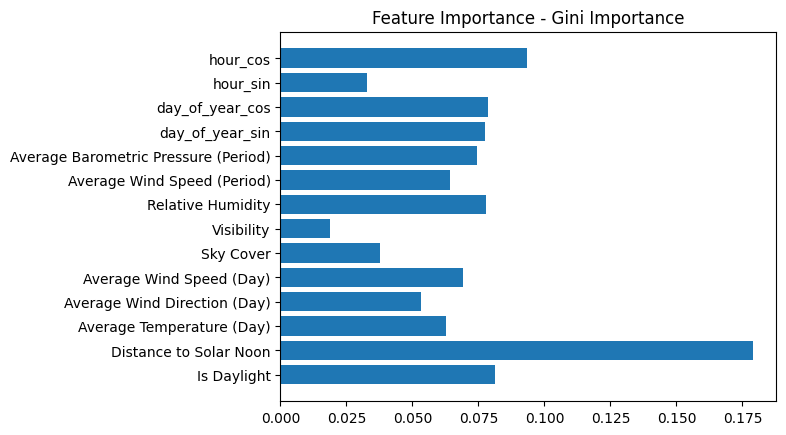

In [34]:
plt.barh(features, feature_importances)
plt.title('Feature Importance - Gini Importance')
plt.show()

In [ ]:
df_original = df_original.drop(columns = ['Visibility', 'Sky Cover'], axis = 1)

Creating synthetic data using KKN Regressor

In [37]:
required_size = 5000
current_size = df_original.shape[0]
extra_needed = required_size - current_size

# Separate features and target variable
X = df_original.drop(columns=["Power Generated"])  # Features
y = df_original["Power Generated"]  # Target

# Train KNN Regressor
knn = KNeighborsRegressor(n_neighbors=3)
knn.fit(X, y)

#unique_hours = df_original['First Hour of Period'].unique()
#num_unique_hours = len(unique_hours)


# Generate synthetic samples
synthetic_X = []
synthetic_y = []
synthetic_hours = []

for i in range(extra_needed):
    idx = np.random.randint(0, current_size)  # Pick a random real sample
    real_sample = X.iloc[idx].to_frame().T  # Keeps feature names
    synthetic_sample = knn.predict(real_sample)  # Predict new value
    synthetic_X.append(real_sample.values[0])  
    synthetic_y.append(synthetic_sample[0])
    #synthetic_hours.append(unique_hours[i % num_unique_hours])
# Convert synthetic data to DataFrame
df_synthetic = pd.DataFrame(synthetic_X, columns=X.columns)
df_synthetic["Power Generated"] = synthetic_y
#df_synthetic['First Hour of Period'] = synthetic_hours

# Combine with original dataset
df_extended = pd.concat([df_original, df_synthetic], ignore_index=True)


# Print dataset sizes
print(f"Original dataset size: {current_size}")
print(f"New dataset size: {df_extended.shape[0]}")

Original dataset size: 2919
New dataset size: 5000


In [38]:
df_extended.to_csv('synthetic.csv', index = False, encoding = 'utf-8')

In [39]:
df = pd.read_csv("synthetic.csv")

Evaluating the synthetic data

In [40]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
X = df_original.drop(columns=["Power Generated"])
y = df_original["Power Generated"]

X_ext = df.drop(columns=["Power Generated"])
y_ext = df["Power Generated"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
X_train_ext, X_test_ext, y_train_ext, y_test_ext = train_test_split(X_ext, y_ext, test_size=0.2)

# Train the model on both datasets
model_real = RandomForestRegressor( )
model_real.fit(X_train, y_train)

model_extended = RandomForestRegressor()
model_extended.fit(X_train_ext, y_train_ext)

# Make predictions
y_pred_real = model_real.predict(X_test)
y_pred_extended = model_extended.predict(X_test_ext)

# Compute SSE (Sum of Squared Errors)
sse_real = np.sum((y_test - y_pred_real) ** 2)
sse_extended = np.sum((y_test_ext - y_pred_extended) ** 2)

# Compute MSE (Mean Squared Error)
mse_real = mean_absolute_error(y_test, y_pred_real)
mse_extended = mean_absolute_error(y_test_ext, y_pred_extended)

print(f"Original Data SSE: {sse_real:.4f}")
print(f"Extended Data SSE: {sse_extended:.4f}")
print(f"Original Data MSE: {mse_real:.4f}")
print(f"Extended Data MSE: {mse_extended:.4f}")

Original Data SSE: 4477229421.5958
Extended Data SSE: 5210432701.1162
Original Data MSE: 1281.2904
Extended Data MSE: 923.1942


In [ ]:
import matplotlib.pyplot as plt 
import seaborn as sns

Comparing the Distribution of Particular Features

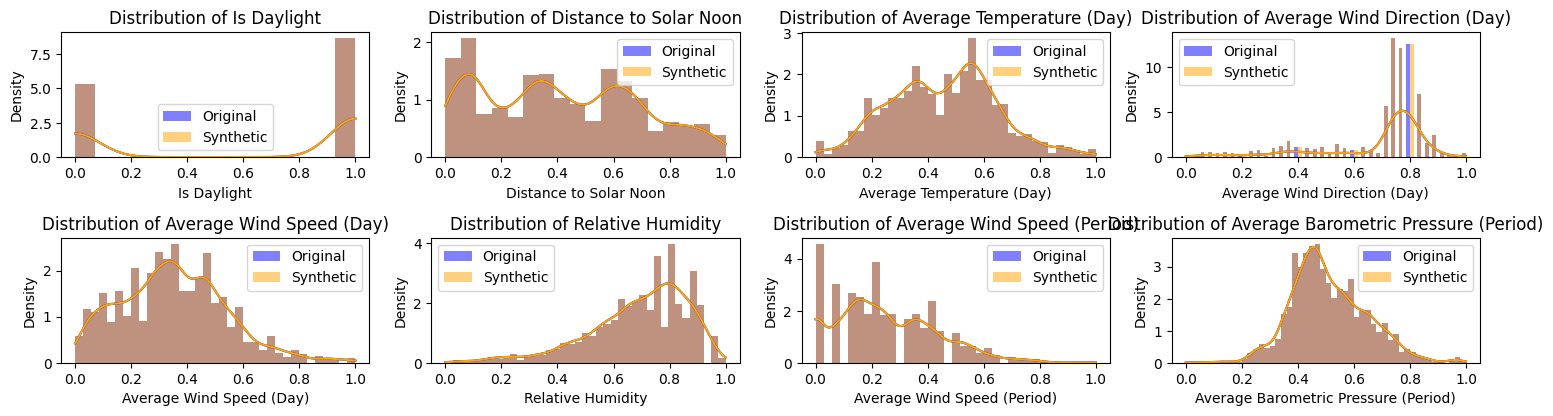

In [42]:
feature_columns = [
   "Is Daylight",
    "Distance to Solar Noon", "Average Temperature (Day)", "Average Wind Direction (Day)", 
    "Average Wind Speed (Day)", "Relative Humidity", 
    "Average Wind Speed (Period)", "Average Barometric Pressure (Period)"
]

# Plot histograms for each feature to compare distributions
plt.figure(figsize=(15, 10))
for i, col in enumerate(feature_columns, 1):
    plt.subplot(5, 4, i)
    sns.histplot(df[col], kde=True, color='blue', label='Original', stat='density', linewidth=0)
    sns.histplot(df_extended[col], kde=True, color='orange', label='Synthetic', stat='density', linewidth=0)
    plt.title(f'Distribution of {col}')
    plt.legend()

plt.tight_layout()
plt.show()